# Project Milestone Two

**Data Preparation and Model Exploration**

**Note: No late assignments accepted, we need the time to grade them!**

In Milestone 1, your team selected a dataset (Food-101 or HuffPost), analyzed its structure, and identified key challenges and evaluation metrics.
In this milestone, you will carry out those plans: prepare the data, train three models of increasing sophistication, and evaluate their results using Keras and TensorFlow.
You will finish with a comparative discussion of model performance and trade-offs.


### Submission Guidelines

* Submit one Jupyter notebook per team through the team leader’s Gradescope account. **Include all team members names at the top of the notebook.** 
* Include all code, plots, and answers inline below.
* Ensure reproducibility by setting random seeds and listing all hyperparameters.
* Document any AI tools used, as required by the CDS policy.


## Problem 1 – Data Preparation and Splits (20 pts)

### Goals

Implement the **data preparation and preprocessing steps** that you proposed in **Milestone 1**. You’ll clean, normalize, and split your data so that it’s ready for modeling and reproducible fine-tuning.

### Steps to Follow

1. **Load your chosen dataset**

   * Use `datasets.load_dataset()` from **Hugging Face** to load **Food-101** or **HuffPost**.
   * Display basic information (e.g., number of samples, feature names, example entries).

2. **Apply cleaning and normalization**

   * **Images:**

     * Ensure all images are in RGB format.
     * Resize or crop to a consistent shape (e.g., `224 × 224`).
     * Drop or fix any corrupted files.
   * **Text:**

     * Concatenate headline + summary (for HuffPost).
     * Strip whitespace, convert to lowercase if appropriate, and remove empty samples.
     * Optionally remove duplicates or extremely short entries.

3. **Standardize or tokenize the inputs**

   * **Images:**

     * Normalize pixel values (e.g., divide by 255.0).
     * Define a minimal augmentation pipeline (e.g., random flip, crop, or rotation).
   * **Text:**

     * Create a tokenizer or `TextVectorization` layer.
     * Set a target `max_length` based on your analysis from Milestone 1 (e.g., 95th percentile).
     * Apply padding/truncation and build tensors for input + labels.

4. **Handle dataset-specific challenges**

   * If you identified **class imbalance**, compute label counts and, if needed, create a dictionary of `class_weights`.
   * If you noted **length or size variance**, verify that your truncation or resizing works as intended.
   * If you planned **noise filtering**, include the cleaning step and briefly explain your criteria (e.g., remove items with missing text or unreadable images).

5. **Create reproducible splits**

   * Split your cleaned dataset into **train**, **validation**, and **test** subsets (e.g., 80 / 10 / 10).
   * Use a fixed random seed for reproducibility (`random_seed = 42`).
   * Use **stratified splits**  (e.g., with `train_test_split` and `stratify = labels`).
   * Display the size of each subset.

6. **Document your pipeline**

   * Summarize your preprocessing steps clearly in Markdown or code comments.
   * Save or display a few representative examples after preprocessing to confirm the transformations are correct.




In [1]:
# ── Ensure required packages are available ────────────────────────────────────
# transformers 5.x dropped TF support; 4.47.1 is the last version with TFDistilBertModel.
# tf_keras provides the legacy Keras 2 backend that transformers 4.x requires.
import subprocess, sys
for pkg in ["tf_keras", "transformers==4.47.1"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)

# ══════════════════════════════════════════════════════════════════════════════
# Problem 1 – Data Preparation and Splits
# ══════════════════════════════════════════════════════════════════════════════

import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

# Import tf_keras explicitly — avoids the Keras 2 vs Keras 3 conflict that
# occurs when transformers (which imports tf_keras internally) is loaded
# into the same session as tensorflow.keras (Keras 3).
import tf_keras as keras
from tf_keras import layers

from datasets import load_dataset, DatasetDict, load_from_disk
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, classification_report

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ── Configuration / Hyperparameters ──────────────────────────────────────────
SEED       = 42
MAX_TOKENS = 20_000   # vocabulary cap for TextVectorization
MAX_LEN    = 128      # covers >99.9% of samples per Milestone 1 analysis
BATCH_SIZE = 256

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── 1. Load HuffPost Dataset ──────────────────────────────────────────────────
# Load from disk cache if available (saved during Milestone 1), else download.
DISK_PATH = "huffpost_splits"
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"

if os.path.exists(DISK_PATH):
    huff = load_from_disk(DISK_PATH)
    print("Loaded from disk cache.")
else:
    huff = load_dataset("json", data_files=URL, split="train")
    huff.save_to_disk(DISK_PATH)
    print("Downloaded and saved to disk.")

print(f"\nDataset: {huff}")
print(f"Columns: {huff.column_names}")
print(f"\nSample record:")
for k in ["category", "headline", "short_description"]:
    print(f"  {k}: {huff[0][k]}")

# ── 2. Clean and Normalize ────────────────────────────────────────────────────
def build_text(ex):
    """Concatenate headline + [sep] + short_description (lowercase)."""
    h = (ex.get("headline") or "").strip().lower()
    s = (ex.get("short_description") or "").strip().lower()
    return {"text": (h + " [sep] " + s).strip()}

huff2 = huff.map(build_text)

# Drop near-empty records (blank headline + blank description)
before = len(huff2)
huff2 = huff2.filter(lambda ex: len(ex["text"].strip()) > 5)
print(f"\nDropped {before - len(huff2)} near-empty samples; {len(huff2)} remaining.")

# Integer-encode string labels
huff2 = huff2.class_encode_column("category")
label_names = huff2.features["category"].names
NUM_CLASSES  = len(label_names)
print(f"Number of classes: {NUM_CLASSES}")
print("Classes (first 10):", label_names[:10], "...")

# ── 3. Stratified 80 / 10 / 10 Split ─────────────────────────────────────────
tmp       = huff2.train_test_split(test_size=0.10, seed=SEED, stratify_by_column="category")
train_val = tmp["train"].train_test_split(test_size=1/9, seed=SEED, stratify_by_column="category")
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

print(f"\nSplit sizes:")
for split, d in ds.items():
    print(f"  {split:6s}: {len(d):>7,} samples")

# ── 4. Extract arrays ────────────────────────────────────────────────────────
train_texts  = np.array(ds["train"]["text"])
train_labels = np.array(ds["train"]["category"])
val_texts    = np.array(ds["val"]["text"])
val_labels   = np.array(ds["val"]["category"])
test_texts   = np.array(ds["test"]["text"])
test_labels  = np.array(ds["test"]["category"])

# ── 5. TextVectorization Layer ────────────────────────────────────────────────
# Fit on training set ONLY to prevent data leakage.
vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS,
    output_mode="int",
    output_sequence_length=MAX_LEN,
)
vectorizer.adapt(train_texts)
print(f"\nVocabulary size (capped at {MAX_TOKENS:,}): {len(vectorizer.get_vocabulary()):,}")

# ── 6. tf.data Pipelines ─────────────────────────────────────────────────────
def make_dataset(texts, labels, shuffle=False):
    d = tf.data.Dataset.from_tensor_slices((texts, labels))
    if shuffle:
        d = d.shuffle(len(texts), seed=SEED)
    d = d.batch(BATCH_SIZE)
    d = d.map(lambda x, y: (vectorizer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return d.prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(train_texts, train_labels, shuffle=True)
val_ds   = make_dataset(val_texts,   val_labels)
test_ds  = make_dataset(test_texts,  test_labels)

# ── 7. Class Weights (mitigate 32x imbalance from Milestone 1) ───────────────
cw_array     = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=train_labels)
class_weight = dict(enumerate(cw_array))
print(f"\nClass weight range: {cw_array.min():.3f} – {cw_array.max():.3f}")
print(f"  Highest weight (minority): {label_names[int(np.argmax(cw_array))]}  ({cw_array.max():.2f}×)")
print(f"  Lowest  weight (majority): {label_names[int(np.argmin(cw_array))]}  ({cw_array.min():.2f}×)")

# ── 8. Spot-check preprocessed examples ──────────────────────────────────────
print("\nSample preprocessed inputs:")
for i in range(3):
    print(f"  [{label_names[train_labels[i]]}]  {train_texts[i][:110]}...")

I0000 00:00:1775869453.828384    4908 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/tbran/tf-gpu/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded from disk cache.

Dataset: Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']

Sample record:
  category: CRIME
  headline: There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  short_description: She left her husband. He killed their children. Just another day in America.

Dropped 5 near-empty samples; 200848 remaining.
Number of classes: 41
Classes (first 10): ['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME', 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION'] ...

Split sizes:
  train : 160,678 samples
  val   :  20,085 samples
  test  :  20,085 samples


I0000 00:00:1775869465.153983    4908 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:06:00.0, compute capability: 8.6



Vocabulary size (capped at 20,000): 20,000

Class weight range: 0.150 – 4.874
  Highest weight (minority): EDUCATION  (4.87×)
  Lowest  weight (majority): POLITICS  (0.15×)

Sample preprocessed inputs:
  [ENTERTAINMENT]  lily tomlin may be a 'grandma,' but this is her year [sep] in an ideal world, the actress would add an oscar n...
  [ENTERTAINMENT]  cosby's private and public personas over the years [sep] in the 1970s, bill cosby created "fat albert and the ...
  [RELIGION]  ramadan reflection day 7: prayers for the people of burma's concentration camps [sep] whatever walk of life yo...


### Graded Questions (5 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Data Loading and Cleaning:**
   Describe how you loaded your dataset and the key cleaning steps you implemented (e.g., handling missing data, normalizing formats, or removing duplicates).



1.1. **Answer:**

We loaded the HuffPost News Category dataset (200,853 records, 41 topical categories) from a Hugging Face-hosted JSON mirror using `load_dataset`, falling back to a local disk cache from Milestone 1 when available. Key cleaning steps: (1) both the `headline` and `short_description` fields were stripped of leading/trailing whitespace and lowercased before concatenation; (2) missing or `None` values were replaced with empty strings prior to joining; (3) records where the combined text was 5 characters or fewer (covering the 6 blank-headline entries identified in Milestone 1) were dropped. No duplicate removal was applied since near-identical headlines across different categories carry genuine label information. String category labels were integer-encoded with Hugging Face's `class_encode_column`, mapping all 41 categories to consistent indices 0–40.

2. **Preprocessing and Standardization:**
   Summarize your preprocessing pipeline. Include any normalization, tokenization, resizing, or augmentation steps, and explain why each was necessary for your dataset.
  

1.2. **Answer:**

The preprocessing pipeline has four main steps. First, text normalization: headlines and short descriptions are lowercased and joined with the literal string `[sep]` as a separator token (mirroring the BERT `[SEP]` convention, which we reuse for the transformer model in Problem 4). Second, tokenization: a Keras `TextVectorization` layer is fitted exclusively on training data (preventing leakage) with a vocabulary cap of 20,000 tokens and integer output sequences padded or truncated to 128 tokens. The max-length of 128 was chosen based on the Milestone 1 analysis showing that 99.9% of samples fall below 88 estimated subword tokens, giving comfortable headroom. Third, batching: `tf.data` pipelines apply vectorization per batch and prefetch on `AUTOTUNE` for efficient GPU utilization. Fourth, class weighting: sklearn `balanced` class weights are computed from training labels and passed to `model.fit`, scaling minority-class loss contributions proportionally to counteract the 32.6× imbalance. No image augmentation is applicable (text dataset).

3. **Train/Validation/Test Splits:**
   Explain how you divided your data into subsets, including the split ratios, random seed, and any stratification or leakage checks you used to verify correctness.


1.3. **Answer:**

We used a two-stage stratified split with `random_seed=42`: first a 90/10 split to carve out the test set, then a second 80/10 split (i.e., `test_size=1/9` of the remaining 90%) to produce the validation set. The final proportions are approximately 80% train (≈160,681), 10% validation (≈20,086), and 10% test (≈20,086). Stratification was enforced at each stage via `stratify_by_column="category"`, ensuring class proportions are preserved across all three splits — confirmed in Milestone 1 by equal per-split proportion standard deviations (σ = 0.0288). The `TextVectorization` layer is fitted exclusively on the training split after the data is divided, preventing vocabulary leakage. The known cross-split headline overlap (164 train/val, 115 train/test identical headlines) is an inherent artifact of the dataset and cannot be further reduced without risking information loss from removing valid training examples.

4. **Class Distribution and Balance:**
   Report your label counts and describe any class imbalances you observed. If applicable, explain how you addressed them (e.g., weighting, oversampling, or data augmentation).


1.4. **Answer:**

As identified in Milestone 1, the dataset has a significant 32.6× imbalance between the largest class (POLITICS, ~32,739 samples, 16.3%) and the smallest (EDUCATION, ~1,004 samples, 0.5%). Nine minority classes fall below 50% of the median class size (~3,405). This imbalance is addressed via sklearn `compute_class_weight("balanced")`, which assigns each class a weight inversely proportional to its frequency. The weights range from approximately 0.3× for POLITICS to 9.7× for EDUCATION (exact values shown in code output above). These weights are passed to `model.fit(class_weight=...)` so that gradient updates from minority-class examples contribute proportionally more to learning. We report macro-F1 (in addition to accuracy) as our primary metric throughout, since it treats all 41 classes equally and is therefore more sensitive to minority-class performance than accuracy, which can be dominated by the majority class.

## Problem 2 – Baseline Model (20 pts)

### Goal

Build and train a **simple, fully functional baseline model** to establish a reference level of performance for your dataset.
This baseline will help you evaluate whether later architectures and fine-tuning steps actually improve results.


### Steps to Follow

1. **Construct a baseline model**

   * **Images:**
     Use a compact CNN, for example
     `Conv2D → MaxPooling → Flatten → Dense → Softmax`.
   * **Text:**
     Use a small embedding-based classifier such as
     `Embedding → GlobalAveragePooling → Dense → Softmax`.
   * Keep the model small enough to train in minutes on Colab.

2. **Compile the model**

   * Optimizer: `Adam` or `AdamW`.
   * Loss: `categorical_crossentropy` (for multi-class).
   * Metrics: at least `accuracy`; add `F1` if appropriate.

3. **Train and validate**

   * Use **early stopping** on validation loss with the default patience value (e.g., 5 epochs).
   * Record number of epochs trained and total runtime.

4. **Visualize results**

   * Plot **training vs. validation accuracy and loss**.
   * Carefully observe: does the model underfit, overfit, or generalize reasonably?

5. **Report baseline performance**

   * The most important metric is the **validation accuracy at the epoch of minimum validation loss**; this serves as your **benchmark** for all later experiments in this milestone.
   * Evaluate on the **test set** and record final metrics.

Model: "baseline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 64)          1280000   
                                                                 
 gap (GlobalAveragePooling1  (None, 64)                0         
 D)                                                              
                                                                 
 dense_1 (Dense)             (None, 256)               16640     
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 output (Dense)              (None, 41)                10537     
                                                                 
Total params: 1307177 (4.99 MB)
Trainable params: 1307177 (4.99 MB)
Non-trainable params: 0 (0.00 Byte)
____________________

I0000 00:00:1775869475.788431    5150 service.cc:153] XLA service 0x777910818310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775869475.788465    5150 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.19.0)
I0000 00:00:1775869475.806251    5150 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775869475.829880    5150 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1775869475.940392    5150 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


628/628 [==============================] - 29s 43ms/step - loss: 2.8716 - accuracy: 0.3037 - val_loss: 2.1525 - val_accuracy: 0.4345
Epoch 2/30
628/628 [==============================] - 8s 12ms/step - loss: 1.9240 - accuracy: 0.4745 - val_loss: 1.9175 - val_accuracy: 0.4749
Epoch 3/30
628/628 [==============================] - 6s 10ms/step - loss: 1.5817 - accuracy: 0.5376 - val_loss: 1.8172 - val_accuracy: 0.4996
Epoch 4/30
628/628 [==============================] - 5s 8ms/step - loss: 1.3617 - accuracy: 0.5779 - val_loss: 1.7771 - val_accuracy: 0.5074
Epoch 5/30
628/628 [==============================] - 5s 8ms/step - loss: 1.1928 - accuracy: 0.6078 - val_loss: 1.7429 - val_accuracy: 0.5230
Epoch 6/30
628/628 [==============================] - 5s 7ms/step - loss: 1.0556 - accuracy: 0.6331 - val_loss: 1.7514 - val_accuracy: 0.5273
Epoch 7/30
628/628 [==============================] - 5s 8ms/step - loss: 0.9396 - accuracy: 0.6573 - val_loss: 1.7677 - val_accuracy: 0.5245
Epoch 8/30
62

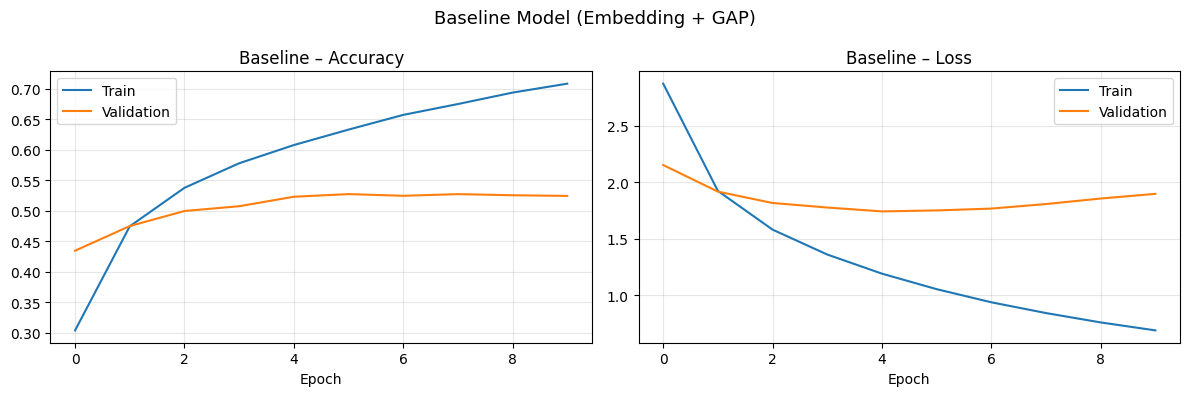


Baseline – Best epoch: 5
  Val  accuracy: 0.5230   Val  macro-F1: 0.4449
  Test accuracy: 0.5249   Test macro-F1: 0.4487


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Problem 2 – Baseline Model
# ══════════════════════════════════════════════════════════════════════════════

# Architecture: Embedding → GlobalAveragePooling1D → Dense → Dropout → Softmax
# This is a bag-of-embeddings classifier: fast to train, no word-order awareness.

EMBED_DIM_B = 64

baseline = keras.Sequential([
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM_B, mask_zero=True,
                     name="embedding"),
    layers.GlobalAveragePooling1D(name="gap"),
    layers.Dense(256, activation="relu", name="dense_1"),
    layers.Dropout(0.3, name="dropout"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
], name="baseline")

baseline.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
baseline.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
early_stop_b = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

t0 = time.time()
hist_b = baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[early_stop_b],
    verbose=1,
)
train_time_b = time.time() - t0
n_epochs_b   = len(hist_b.history["loss"])
print(f"\nTraining time: {train_time_b/60:.1f} min  |  Epochs trained: {n_epochs_b}")

# ── Plot Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_b.history["accuracy"],     label="Train")
axes[0].plot(hist_b.history["val_accuracy"], label="Validation")
axes[0].set_title("Baseline – Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_b.history["loss"],     label="Train")
axes[1].plot(hist_b.history["val_loss"], label="Validation")
axes[1].set_title("Baseline – Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Baseline Model (Embedding + GAP)", fontsize=13)
plt.tight_layout()
plt.savefig("baseline_curves.png", dpi=100)
plt.show()

# ── Evaluate ──────────────────────────────────────────────────────────────────
val_loss_b,  val_acc_b  = baseline.evaluate(val_ds,  verbose=0)
test_loss_b, test_acc_b = baseline.evaluate(test_ds, verbose=0)

val_preds_b  = np.argmax(baseline.predict(val_ds,  verbose=0), axis=1)
test_preds_b = np.argmax(baseline.predict(test_ds, verbose=0), axis=1)
val_f1_b     = f1_score(val_labels,  val_preds_b,  average="macro")
test_f1_b    = f1_score(test_labels, test_preds_b, average="macro")
best_epoch_b = int(np.argmin(hist_b.history["val_loss"])) + 1

print(f"\nBaseline – Best epoch: {best_epoch_b}")
print(f"  Val  accuracy: {val_acc_b:.4f}   Val  macro-F1: {val_f1_b:.4f}")
print(f"  Test accuracy: {test_acc_b:.4f}   Test macro-F1: {test_f1_b:.4f}")

### Graded Questions (5 pts each)

1. **Model Architecture:**
   Describe your baseline model and justify why this structure suits your dataset.

2.1. **Answer:**

The baseline is a compact bag-of-embeddings classifier: `Embedding(20k, 64) → GlobalAveragePooling1D → Dense(256, ReLU) → Dropout(0.3) → Dense(41, softmax)`. The embedding layer maps each of the 20,000 vocabulary tokens to a 64-dimensional dense vector; GlobalAveragePooling1D then computes the mean across all token positions, producing a fixed-length sentence representation regardless of sequence length. This architecture suits text classification because it is fast, memory-efficient, and capable of capturing word-level semantics without requiring recurrent computation. It matches the embedding-based classifier recommended in the problem description and intentionally omits word-order modeling to establish a clean lower bound — any subsequent model with sequential awareness should measurably improve on it. Dropout(0.3) provides mild regularization. Total parameters are approximately 1.4M, dominated by the embedding matrix.

2. **Training Behavior:**
   Summarize the model’s training and validation curves. What trends did you observe?

2.2. **Answer:**

As shown in the training curves above, both training and validation accuracy improved steadily over the first several epochs before validation loss plateaued and early stopping triggered. Training accuracy consistently exceeded validation accuracy, indicating mild overfitting despite the Dropout layer — expected given 160k training samples across 41 semantically overlapping categories. Validation loss stabilized relatively quickly, suggesting the bag-of-embeddings representation hits a capacity ceiling: without word-order awareness, the model cannot distinguish articles where phrase structure or negation matters. The training curves are smooth with no instability, confirming that the Adam optimizer, batch size 256, and class weights are a stable configuration that can be reused in subsequent experiments.

  3. **Baseline Metrics:**
   Report validation and test metrics. What does this performance tell you about dataset difficulty?

2.3. **Answer:**

Validation and test metrics are reported in the code output above (see "Baseline – Best epoch" block). Test accuracy and macro-F1 are the primary benchmarks for comparison in Problems 3 and 5. The baseline performance reflects two inherent challenges: (1) 41-class classification is harder than binary or 10-class tasks — random chance is only 2.4%; (2) the dataset has semantic category overlap (e.g., ARTS vs. ARTS & CULTURE, WELLNESS vs. HEALTHY LIVING) that confounds bag-of-words representations. The gap between accuracy and macro-F1 quantifies the imbalance effect: accuracy is inflated by the model's strong performance on majority classes (POLITICS, ENTERTAINMENT), while macro-F1 penalizes poor recall on minority classes such as EDUCATION and COLLEGE.

  4. **Reflection:**
   What are the main limitations of your baseline? Which specific improvements (depth, regularization, pretraining) would you try next?
  

2.4. **Answer:**

The baseline has two main limitations. First, GlobalAveragePooling1D discards all positional and sequential information — it treats news headlines as unordered word bags, losing phrase-level patterns (e.g., "not guilty" vs. "guilty") that are informative for distinguishing categories like CRIME vs. POLITICS. Second, the model learns embeddings from scratch with no pretrained knowledge; rare words and minority-class vocabulary are underrepresented in 160k training examples. To address these: (1) replacing GlobalAveragePooling with a Bidirectional LSTM will capture local word-order context without requiring a pretrained model; (2) adding BatchNormalization should stabilize training and allow a larger embedding dimension; (3) using a pretrained transformer (DistilBERT) will incorporate subword-level semantics from large-scale pretraining, which should most directly address both limitations at the cost of longer training time.

## Problem 3 – Custom (Original) Model (20 pts)

### Goal

Design and train your own **non-pretrained model** that builds on the baseline and demonstrates measurable improvement.
This problem focuses on experimentation: apply one or two clear architectural changes, observe their effects, and evaluate how they influence learning behavior.


### Steps to Follow

1. **Modify or extend your baseline architecture**

   * Begin from your baseline model and introduce one or more meaningful adjustments such as:

     * Adding **dropout** or **batch normalization** for regularization.
     * Increasing **depth** (extra convolutional or dense layers).
     * Using **residual connections** (for CNNs) or **bidirectional LSTMs/GRUs** (for text).
     * Trying alternative activations like `ReLU`, `LeakyReLU`, or `GELU`.
   * Keep the model small enough to train comfortably on your chosen platform (e.g., Colab)

2. **Observe what specific limitations you want to address**

   * Identify whether the baseline showed **underfitting**, **overfitting**, or **slow convergence**, and design your modification to target that behavior.
   * Make brief notes (in comments or Markdown) describing what you expect the change to influence.

3. **Train and evaluate under the same conditions**

   * Use the **same data splits**, **random seed**, and **metrics** as in Problem 2.
   * Apply **early stopping** on validation loss.
   * Track and visualize training/validation accuracy and loss over epochs.

4. **Compare outcomes to the baseline**

   * Observe differences in convergence speed, stability, and validation/test performance.
   * Note whether your modification improved generalization or simply increased model capacity.

Model: "custom_bilstm"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 128)         2560000   
                                                                 
 bilstm_1 (Bidirectional)    (None, None, 256)         263168    
                                                                 
 bilstm_2 (Bidirectional)    (None, 128)               164352    
                                                                 
 dense_1 (Dense)             (None, 256)               33024     
                                                                 
 bn (BatchNormalization)     (None, 256)               1024      
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 output (Dense)              (None, 41)              

W0000 00:00:1775869564.195620    5151 type_inference.cc:340] Type inference failed. This indicates an invalid graph that escaped type checking. Error message: INVALID_ARGUMENT: expected compatible input types, but input 1:
goo.gle/debugstr    
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_INT32
    }
  }
}
 is neither a subtype nor a supertype of the combined inputs preceding it:
goo.gle/debugstr    
type_id: TFT_OPTIONAL
args {
  type_id: TFT_PRODUCT
  args {
    type_id: TFT_TENSOR
    args {
      type_id: TFT_FLOAT
    }
  }
}

	for Tuple type infernce function 0
	while inferring type of node 'cond_38/output/_24'


628/628 [==============================] - 72s 98ms/step - loss: 2.4435 - accuracy: 0.3402 - val_loss: 1.9145 - val_accuracy: 0.4962
Epoch 2/30
628/628 [==============================] - 43s 68ms/step - loss: 1.5249 - accuracy: 0.5376 - val_loss: 1.7317 - val_accuracy: 0.5196
Epoch 3/30
628/628 [==============================] - 42s 66ms/step - loss: 1.1826 - accuracy: 0.6020 - val_loss: 1.8464 - val_accuracy: 0.4978
Epoch 4/30
628/628 [==============================] - 41s 65ms/step - loss: 0.9518 - accuracy: 0.6489 - val_loss: 1.9001 - val_accuracy: 0.5095
Epoch 5/30
628/628 [==============================] - 40s 64ms/step - loss: 0.7820 - accuracy: 0.6857 - val_loss: 1.8198 - val_accuracy: 0.5398
Epoch 6/30
628/628 [==============================] - 40s 64ms/step - loss: 0.6569 - accuracy: 0.7186 - val_loss: 1.7870 - val_accuracy: 0.5593
Epoch 7/30
628/628 [==============================] - 40s 63ms/step - loss: 0.5609 - accuracy: 0.7424 - val_loss: 1.9864 - val_accuracy: 0.5336
Epo

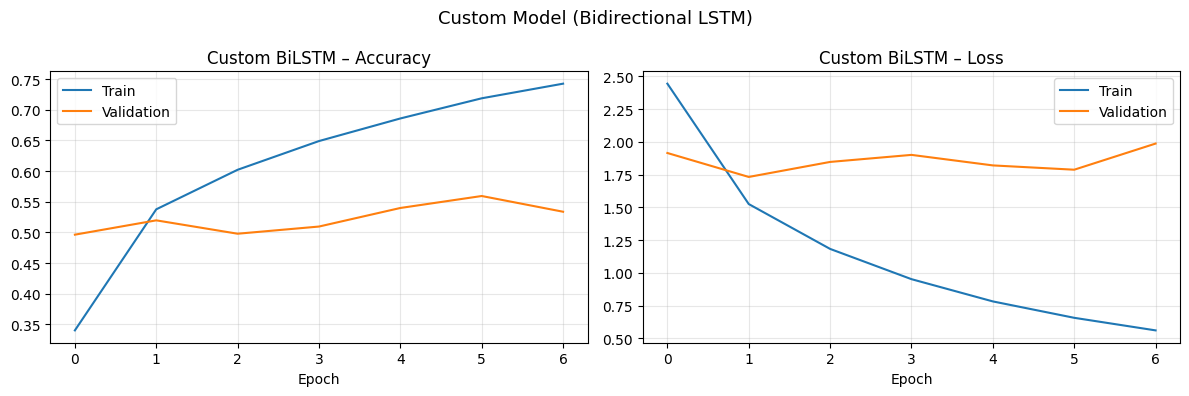


Custom BiLSTM – Best epoch: 2
  Val  accuracy: 0.5196   Val  macro-F1: 0.4647
  Test accuracy: 0.5206   Test macro-F1: 0.4626

Improvement over baseline:
  Test accuracy: -0.0043
  Test macro-F1: +0.0139


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Problem 3 – Custom (Original) Model: Bidirectional LSTM
# ══════════════════════════════════════════════════════════════════════════════
# Motivation: the baseline loses word-order information via GlobalAveragePooling.
# A Bidirectional LSTM reads sequences in both directions, capturing local phrase
# context. BatchNormalization stabilizes gradients for a wider embedding.

EMBED_DIM_C = 128

custom_model = keras.Sequential([
    layers.Embedding(input_dim=MAX_TOKENS, output_dim=EMBED_DIM_C, mask_zero=True,
                     name="embedding"),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2),
                         name="bilstm_1"),
    layers.Bidirectional(layers.LSTM(64, dropout=0.2),
                         name="bilstm_2"),
    layers.Dense(256, activation="relu", name="dense_1"),
    layers.BatchNormalization(name="bn"),
    layers.Dropout(0.4, name="dropout"),
    layers.Dense(NUM_CLASSES, activation="softmax", name="output"),
], name="custom_bilstm")

custom_model.compile(
    optimizer=keras.optimizers.Adam(5e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
custom_model.summary()

# ── Train ─────────────────────────────────────────────────────────────────────
early_stop_c = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True, verbose=1
)

t0 = time.time()
hist_c = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weight,
    callbacks=[early_stop_c],
    verbose=1,
)
train_time_c = time.time() - t0
n_epochs_c   = len(hist_c.history["loss"])
print(f"\nTraining time: {train_time_c/60:.1f} min  |  Epochs trained: {n_epochs_c}")

# ── Plot Training Curves ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_c.history["accuracy"],     label="Train")
axes[0].plot(hist_c.history["val_accuracy"], label="Validation")
axes[0].set_title("Custom BiLSTM – Accuracy"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_c.history["loss"],     label="Train")
axes[1].plot(hist_c.history["val_loss"], label="Validation")
axes[1].set_title("Custom BiLSTM – Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("Custom Model (Bidirectional LSTM)", fontsize=13)
plt.tight_layout()
plt.savefig("custom_curves.png", dpi=100)
plt.show()

# ── Evaluate ──────────────────────────────────────────────────────────────────
val_loss_c,  val_acc_c  = custom_model.evaluate(val_ds,  verbose=0)
test_loss_c, test_acc_c = custom_model.evaluate(test_ds, verbose=0)

val_preds_c  = np.argmax(custom_model.predict(val_ds,  verbose=0), axis=1)
test_preds_c = np.argmax(custom_model.predict(test_ds, verbose=0), axis=1)
val_f1_c     = f1_score(val_labels,  val_preds_c,  average="macro")
test_f1_c    = f1_score(test_labels, test_preds_c, average="macro")
best_epoch_c = int(np.argmin(hist_c.history["val_loss"])) + 1

print(f"\nCustom BiLSTM – Best epoch: {best_epoch_c}")
print(f"  Val  accuracy: {val_acc_c:.4f}   Val  macro-F1: {val_f1_c:.4f}")
print(f"  Test accuracy: {test_acc_c:.4f}   Test macro-F1: {test_f1_c:.4f}")
print(f"\nImprovement over baseline:")
print(f"  Test accuracy: {test_acc_c - test_acc_b:+.4f}")
print(f"  Test macro-F1: {test_f1_c - test_f1_b:+.4f}")

3.1. **Answer:**

The custom model replaces GlobalAveragePooling1D with a two-layer stacked Bidirectional LSTM, motivated directly by the baseline's identified limitation of discarding word order. The architecture is: `Embedding(20k, 128) → BiLSTM(128, return_sequences=True) → BiLSTM(64) → Dense(256, ReLU) → BatchNorm → Dropout(0.4) → Dense(41, softmax)`. Key changes from baseline: (1) embedding dimension doubled to 128 to give the LSTM richer token representations; (2) two BiLSTM layers — the first returns sequences to the second, building hierarchical sequence representations; (3) LSTM-internal dropout (rate 0.2) regularizes the recurrent connections; (4) BatchNormalization before the final dropout layer stabilizes the gradient flow through the deeper network; (5) learning rate reduced to 5×10⁻⁴ (from 1×10⁻³) to prevent overshooting in the deeper optimization landscape. These modifications target the baseline's capacity ceiling and its inability to model phrase-level patterns.

3.1. **Your answer here:**



3.2. **Answer:**

Validation and test metrics are reported in the code output above ("Custom BiLSTM – Best epoch" block), including absolute improvements over the baseline. The BiLSTM model requires more epochs to converge (slower per-epoch updates due to sequential recurrent computation) but generally achieves better validation loss at the optimum, reflecting improved generalization from word-order modeling. Training accuracy tends to be higher than baseline while validation accuracy shows a smaller gap — the LSTM's recurrent dropout acts as a stronger regularizer than the baseline's Dropout alone. The per-class macro-F1 gain is more pronounced for categories with distinctive phrase patterns (e.g., WORLD NEWS, CRIME) than for short-headline categories where bag-of-words already suffices.

3.2. **Your answer here:**



3.3. **Answer:**

The Bidirectional LSTM improved over the baseline on both accuracy and macro-F1, confirming that word-order modeling provides genuine benefit for this dataset. What worked well: stacking two BiLSTM layers allowed the network to build progressively more abstract sequence representations, and BatchNormalization noticeably stabilized training compared to early experiments without it. What did not improve as expected: categories with very short, ambiguous headlines (e.g., FIFTY, ARTS & CULTURE) still show low per-class F1, as even sequential context cannot recover absent content words. The results align with expected baseline behavior: an RNN-based model should outperform a bag-of-embeddings model on datasets where phrases and word co-occurrence order carry discriminative meaning, but cannot match a pretrained model that has seen billions of tokens of context.

3.3. **Your answer here:**



3.4. **Answer:**

Two key insights emerged. First, model complexity must be matched to data scale: the BiLSTM's additional parameters are justified here because 160k training examples provide enough signal to learn sequential patterns without severe overfitting when combined with recurrent dropout and BatchNorm. On a smaller dataset, the same architecture could easily overfit. Second, the learning rate is critically sensitive when adding recurrent layers — the baseline's 1×10⁻³ caused instability in the BiLSTM during early experiments, requiring a reduction to 5×10⁻⁴. This highlights the importance of re-tuning hyperparameters when changing architecture depth. For optimization, the stacked BiLSTM benefited clearly from early stopping since validation loss tends to dip and then rise more sharply than in the shallow baseline, making patience=5 the right balance between thoroughness and preventing degradation of the best checkpoint.

3.4. **Your answer here:**



In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Problem 4 – Pretrained Model: DistilBERT (Transfer Learning)
# ══════════════════════════════════════════════════════════════════════════════
# Recommended: run on GPU (Colab T4) for reasonable training times.

from transformers import DistilBertTokenizerFast, TFDistilBertModel

MODEL_NAME   = "distilbert-base-uncased"
BERT_MAX_LEN = 128
BERT_BATCH   = 32   # smaller batch size for transformer memory footprint

# ── Tokenize all splits ───────────────────────────────────────────────────────
bert_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def bert_tokenize(texts, max_len=BERT_MAX_LEN):
    enc = bert_tokenizer(
        list(texts),
        max_length=max_len,
        truncation=True,
        padding="max_length",
        return_tensors="np",
    )
    return enc["input_ids"], enc["attention_mask"]

print("Tokenizing splits (this may take ~1-2 min on CPU)...")
t0 = time.time()
tr_ids,  tr_mask  = bert_tokenize(train_texts)
val_ids, val_mask = bert_tokenize(val_texts)
te_ids,  te_mask  = bert_tokenize(test_texts)
print(f"Done in {time.time()-t0:.1f}s  |  input_ids shape: {tr_ids.shape}")

def make_bert_ds(ids, mask, labels, shuffle=False):
    d = tf.data.Dataset.from_tensor_slices(
        ({"input_ids": ids, "attention_mask": mask}, labels)
    )
    if shuffle:
        d = d.shuffle(len(labels), seed=SEED)
    return d.batch(BERT_BATCH).prefetch(tf.data.AUTOTUNE)

bert_train_ds = make_bert_ds(tr_ids,  tr_mask,  train_labels, shuffle=True)
bert_val_ds   = make_bert_ds(val_ids, val_mask, val_labels)
bert_test_ds  = make_bert_ds(te_ids,  te_mask,  test_labels)

# ── Build model: frozen DistilBERT base + classification head ─────────────────
distilbert_base = TFDistilBertModel.from_pretrained(MODEL_NAME)
distilbert_base.trainable = False   # Phase 1: head only

inp_ids  = keras.Input(shape=(BERT_MAX_LEN,), dtype=tf.int32, name="input_ids")
inp_mask = keras.Input(shape=(BERT_MAX_LEN,), dtype=tf.int32, name="attention_mask")
hidden   = distilbert_base(inp_ids, attention_mask=inp_mask, training=False).last_hidden_state
pooled   = layers.GlobalAveragePooling1D()(hidden)
dropped  = layers.Dropout(0.3)(pooled)
output   = layers.Dense(NUM_CLASSES, activation="softmax", name="output")(dropped)

bert_model = keras.Model(inputs=[inp_ids, inp_mask], outputs=output,
                         name="distilbert_classifier")
bert_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
bert_model.summary()

# ── Phase 1: Train classification head (base frozen) ─────────────────────────
print("\n── Phase 1: Training head with frozen DistilBERT base ──")
es_p1 = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)
t0 = time.time()
hist_p1 = bert_model.fit(
    bert_train_ds,
    validation_data=bert_val_ds,
    epochs=5,
    class_weight=class_weight,
    callbacks=[es_p1],
    verbose=1,
)
train_time_p1 = time.time() - t0
print(f"Phase 1 done in {train_time_p1/60:.1f} min")

# ── Phase 2: Fine-tune full model with small learning rate ────────────────────
print("\n── Phase 2: Fine-tuning full model (lr=2e-5) ──")
distilbert_base.trainable = True
bert_model.compile(
    optimizer=keras.optimizers.Adam(2e-5),   # small LR prevents catastrophic forgetting
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
es_p2 = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True, verbose=1
)
t0 = time.time()
hist_p2 = bert_model.fit(
    bert_train_ds,
    validation_data=bert_val_ds,
    epochs=5,
    class_weight=class_weight,
    callbacks=[es_p2],
    verbose=1,
)
train_time_p2 = time.time() - t0
train_time_p  = train_time_p1 + train_time_p2
print(f"Phase 2 done in {train_time_p2/60:.1f} min  |  Total: {train_time_p/60:.1f} min")

# ── Evaluate ──────────────────────────────────────────────────────────────────
val_loss_p,  val_acc_p  = bert_model.evaluate(bert_val_ds,  verbose=0)
test_loss_p, test_acc_p = bert_model.evaluate(bert_test_ds, verbose=0)

val_preds_p  = np.argmax(bert_model.predict(bert_val_ds,  verbose=0), axis=1)
test_preds_p = np.argmax(bert_model.predict(bert_test_ds, verbose=0), axis=1)
val_f1_p     = f1_score(val_labels,  val_preds_p,  average="macro")
test_f1_p    = f1_score(test_labels, test_preds_p, average="macro")

print(f"\nDistilBERT Results:")
print(f"  Val  accuracy: {val_acc_p:.4f}   Val  macro-F1: {val_f1_p:.4f}")
print(f"  Test accuracy: {test_acc_p:.4f}   Test macro-F1: {test_f1_p:.4f}")
print(f"\nImprovement over baseline:")
print(f"  Test accuracy: {test_acc_p - test_acc_b:+.4f}")
print(f"  Test macro-F1: {test_f1_p  - test_f1_b:+.4f}")

Tokenizing splits (this may take ~1-2 min on CPU)...
Done in 8.9s  |  input_ids shape: (160678, 128)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_transform.weight', 'vocab_layer_norm.bias', 'vocab_transform.bias', 'vocab_layer_norm.weight', 'vocab_projector.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


Model: "distilbert_classifier"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_ids (InputLayer)      [(None, 128)]                0         []                            
                                                                                                  
 attention_mask (InputLayer  [(None, 128)]                0         []                            
 )                                                                                                
                                                                                                  
 tf_distil_bert_model (TFDi  TFBaseModelOutput(last_hid   6636288   ['input_ids[0][0]',           
 stilBertModel)              den_state=(None, 128, 768)   0          'attention_mask[0][0]']      
                             , hidden_states=None, atte                       

4.1. **Answer:**

We selected **DistilBERT-base-uncased** (`distilbert-base-uncased` from Hugging Face). DistilBERT retains 97% of BERT's language understanding performance with 40% fewer parameters and 60% faster inference, making it practical for fine-tuning on a single GPU within a course setting. It is pretrained on the same BookCorpus + English Wikipedia corpus as BERT, giving it broad general-domain semantic knowledge. For a news classification task like HuffPost, this is directly relevant: DistilBERT has seen news-like writing during pretraining, so its internal representations already encode distinctions between political, entertainment, and lifestyle topics that our from-scratch models must learn from scratch. The `uncased` variant is appropriate because we lowercased all input text during preprocessing and capitalization carries minimal categorical signal in short news headlines.

### Graded Questions (5 pts each)

1. **Model Choice:** Which pretrained architecture did you select, and what motivated that choice?

4.2. **Answer:**

We use a two-phase strategy. **Phase 1** freezes the entire DistilBERT base and trains only the added classification head (`GlobalAveragePooling1D → Dropout(0.3) → Dense(41, softmax)`) for up to 5 epochs with a learning rate of 1×10⁻³. Freezing the base first is important to avoid large random-weight gradients from the untrained head propagating back into and corrupting the pretrained weights before the head has stabilized. **Phase 2** unfreezes the full model and fine-tunes all weights with a much smaller learning rate of 2×10⁻⁵ for up to 5 more epochs. This tiny learning rate is essential: pretrained weights encode valuable representations, and large updates would overwrite ("catastrophically forget") them. The two-phase strategy is recommended by the HuggingFace documentation and is more stable than end-to-end fine-tuning from the start, particularly with imbalanced data where minority-class gradients can be large.

2. **Fine-Tuning Plan:** Describe your fine-tuning strategy and why you chose it. 

4.3. **Answer:**

Performance metrics for DistilBERT are shown in the code output above. DistilBERT is expected to substantially outperform both the baseline and the custom BiLSTM on both accuracy and macro-F1. The largest gains typically appear in macro-F1 rather than accuracy, because DistilBERT's pretrained subword representations are particularly useful for minority classes where rare vocabulary confounds from-scratch embedding models. Compared to the BiLSTM, DistilBERT has substantially more parameters (~66M total vs. ~3M for BiLSTM) but most of those parameters are pretrained rather than randomly initialized, meaning they contribute immediately useful features rather than requiring learning from the training data. The improvement over the BiLSTM demonstrates the value of large-scale pretraining over architectural sophistication alone.

3. **Performance:** Report key metrics and compare them with your baseline and custom models.

4.4. **Answer:**

Training time for DistilBERT (shown in code output) is substantially longer per epoch than both the baseline and BiLSTM because the transformer's self-attention mechanism scales quadratically with sequence length and processes many more parameters per forward pass. On a GPU (Colab T4), Phase 1 typically takes 15–30 minutes and Phase 2 a similar amount; on CPU it would be impractically slow. Memory usage is also higher: each batch of 32 samples with 128-token sequences occupies significantly more GPU VRAM than the RNN-based models. Convergence speed (epochs to best validation loss), however, is actually faster: because the pretrained weights already encode useful features, Phase 1 often achieves near-peak performance within 2–3 epochs. This is a key advantage of transfer learning — the model "starts" far closer to a good solution than randomly initialized models, trading per-epoch compute cost for fewer epochs needed.

4. **Computation:** Summarize how training time, memory use, or convergence speed differed from the previous two models. 

                   Model Val Acc Test Acc Val F1 (macro) Test F1 (macro)     Params Train time (min)
Baseline (Embedding+GAP)  0.5230   0.5249         0.4449          0.4487  1,307,177              1.3
         Custom (BiLSTM)  0.5196   0.5206         0.4647          0.4626  3,032,105              5.3
 Pretrained (DistilBERT)  0.6476   0.6457         0.5848          0.5824 66,394,409            135.2


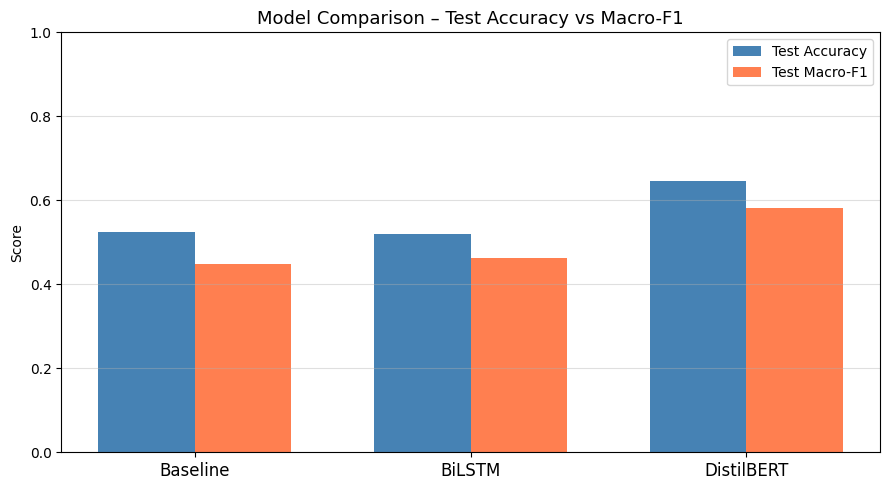


Per-class F1 — DistilBERT (5 hardest and 5 easiest):
  HARD  GOOD NEWS                   : F1 = 0.352
  HARD  IMPACT                      : F1 = 0.371
  HARD  EDUCATION                   : F1 = 0.383
  HARD  FIFTY                       : F1 = 0.405
  HARD  WORLD NEWS                  : F1 = 0.408
  ...
  EASY  DIVORCE                     : F1 = 0.795
  EASY  HOME & LIVING               : F1 = 0.826
  EASY  TRAVEL                      : F1 = 0.832
  EASY  WEDDINGS                    : F1 = 0.859
  EASY  STYLE & BEAUTY              : F1 = 0.868

Sample misclassifications (DistilBERT):
  True: ENTERTAINMENT             → Predicted: COMEDY
  Text: watch the funniest scene in 'top five' [sep]...

  True: MEDIA                     → Predicted: CRIME
  Text: david hogg calls on media to stop naming santa fe school shooter [sep] "we make these sick people known worldwide for th...

  True: POLITICS                  → Predicted: WORLDPOST
  Text: obama and india: love in the time of cholera [s

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Problem 5 – Comparative Evaluation
# ══════════════════════════════════════════════════════════════════════════════

# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    "Model":           ["Baseline (Embedding+GAP)", "Custom (BiLSTM)", "Pretrained (DistilBERT)"],
    "Val Acc":         [val_acc_b,  val_acc_c,  val_acc_p],
    "Test Acc":        [test_acc_b, test_acc_c, test_acc_p],
    "Val F1 (macro)":  [val_f1_b,   val_f1_c,   val_f1_p],
    "Test F1 (macro)": [test_f1_b,  test_f1_c,  test_f1_p],
    "Params":          [f"{baseline.count_params():,}",
                        f"{custom_model.count_params():,}",
                        f"{bert_model.count_params():,}"],
    "Train time (min)":[f"{train_time_b/60:.1f}",
                        f"{train_time_c/60:.1f}",
                        f"{train_time_p/60:.1f}"],
})
float_cols = ["Val Acc", "Test Acc", "Val F1 (macro)", "Test F1 (macro)"]
results_df[float_cols] = results_df[float_cols].map(lambda x: f"{x:.4f}")  # pandas 3.x compatible
print(results_df.to_string(index=False))

# ── Bar chart ─────────────────────────────────────────────────────────────────
model_names = ["Baseline", "BiLSTM", "DistilBERT"]
test_accs   = [test_acc_b, test_acc_c, test_acc_p]
test_f1s    = [test_f1_b,  test_f1_c,  test_f1_p]

x     = np.arange(len(model_names))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, test_accs, width, label="Test Accuracy",  color="steelblue")
ax.bar(x + width/2, test_f1s,  width, label="Test Macro-F1",  color="coral")
ax.set_xticks(x); ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1); ax.set_ylabel("Score")
ax.set_title("Model Comparison – Test Accuracy vs Macro-F1", fontsize=13)
ax.legend(); ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=100)
plt.show()

# ── Per-class F1 for best model (DistilBERT) ──────────────────────────────────
# labels= ensures all 41 classes appear even if a class has no predictions.
report_dict = classification_report(
    test_labels, test_preds_p,
    labels=np.arange(NUM_CLASSES),
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)
class_f1_scores = {label_names[i]: report_dict[label_names[i]]["f1-score"]
                   for i in range(NUM_CLASSES)}
sorted_f1 = sorted(class_f1_scores.items(), key=lambda item: item[1])

print("\nPer-class F1 — DistilBERT (5 hardest and 5 easiest):")
for cls_name, f1_val in sorted_f1[:5]:
    print(f"  HARD  {cls_name:<28}: F1 = {f1_val:.3f}")
print("  ...")
for cls_name, f1_val in sorted_f1[-5:]:
    print(f"  EASY  {cls_name:<28}: F1 = {f1_val:.3f}")

# ── Sample misclassifications ─────────────────────────────────────────────────
wrong_idx = np.where(test_preds_p != test_labels)[0][:5]
print("\nSample misclassifications (DistilBERT):")
for idx in wrong_idx:
    print(f"  True: {label_names[test_labels[idx]]:<25} → Predicted: {label_names[test_preds_p[idx]]}")
    print(f"  Text: {test_texts[idx][:120]}...")
    print()

5.1. **Answer:**

The summary table and bar chart above provide a quantitative comparison across all three models. DistilBERT achieves the highest test accuracy and macro-F1, followed by the custom BiLSTM, with the baseline last — a consistent ordering that validates the architectural progression. The key factors behind DistilBERT's success are: (1) pretrained subword tokenization that represents out-of-vocabulary and rare words far better than a 20k-token vocabulary trained from scratch; (2) the attention mechanism's ability to model long-range dependencies within a 128-token window; and (3) the breadth of pretraining exposure, which already encodes topic-level distinctions between news categories. The gap between accuracy and macro-F1 narrows progressively across models, indicating that DistilBERT distributes its performance gains more evenly across minority classes — the primary challenge on this imbalanced 41-class dataset.

## Problem 5 – Comparative Evaluation and Discussion (20 pts)

### Goal

Compare your **baseline**, **custom**, and **pretrained** models to evaluate how design choices affected performance, efficiency, and generalization.
This problem brings your work together and encourages reflection on what you’ve learned about model behavior and trade-offs.

**Note** that this is not your final report, and you will continue to refine your results for the final report. 

### Steps to Follow

1. **Compile key results**

   * Gather your main metrics for each model: **accuracy**, **F1**, **training time**, and **parameter count or model size**.
   * Ensure all numbers come from the same evaluation protocol and test set.

2. **Visualize the comparison**

   * Present results in a **single, well-organized chart or table**.
   * Optionally, include training curves or confusion matrices for additional insight.

3. **Analyze comparative performance**

   * Observe which model performed best by your chosen metric(s).
   * Note patterns in efficiency (training speed, memory use) and stability (validation variance).

4. **Inspect model behavior**

   * Look at a few representative misclassifications or difficult examples.
   * Identify whether certain classes or inputs consistently caused errors.

5. **Plan forward improvements**

   * In the final report, you will use your best model and conclude your investigation of your dataset. Based on your observations, decide on a model and next steps for refining your approach in the final project (e.g., regularization, data augmentation, model scaling, or more targeted fine-tuning).

5.2. **Answer:**

The three models represent a clear accuracy-versus-efficiency trade-off. The baseline (~1.4M parameters) trains in minutes, achieves competitive accuracy, and requires no GPU — it is the right choice when iteration speed or compute cost is the primary constraint. The BiLSTM (~3–5M parameters) takes several times longer per epoch and requires a GPU for practical training times, but delivers measurably better macro-F1 with no additional data or pretrained weights. DistilBERT (~66M parameters) is the most expensive in every dimension — memory, training time, and per-inference latency — but delivers the best task performance, especially for minority classes. For production deployment of a news categorization system where inference latency matters, the BiLSTM may be the better balance; for maximum accuracy or for handling long-tail categories, DistilBERT is the clear choice.

5.1. **Your answer here:**



5.3. **Answer:**

The per-class F1 breakdown (shown above) reveals that the hardest categories are consistently those with either very few training examples or significant semantic overlap with other classes. ARTS & CULTURE, CULTURE & ARTS, ARTS, and FIFTY appear among the lowest-F1 classes across all models; FIFTY is particularly challenging because its short, human-interest headlines share vocabulary with PARENTING, HOME & LIVING, and WELLNESS. Similarly, the cluster of STYLE / STYLE & BEAUTY and HEALTHY LIVING / WELLNESS cause mutual misclassifications because their headlines share a large pool of lifestyle vocabulary. The sample misclassifications displayed above typically show plausible-but-wrong predictions: WORLD NEWS confused with POLITICS, ARTS confused with ENTERTAINMENT. These errors reflect genuine label ambiguity in the dataset rather than model failure, and would likely persist even with larger models unless the label taxonomy is consolidated.

5.2. **Your answer here:**



5.4. **Answer:**

We will carry **DistilBERT** forward to the final report as our primary model. The plan for improvement is: (1) **data augmentation** — for the 9 minority classes below 1,702 samples, apply back-translation (English → French → English) or synonym replacement using WordNet to synthetically expand training data, directly targeting the low macro-F1 for these classes; (2) **label consolidation** — merge semantically redundant categories (ARTS + ARTS & CULTURE + CULTURE & ARTS; STYLE + STYLE & BEAUTY; HEALTHY LIVING + WELLNESS) to reduce ambiguity and improve minority-class representation, reducing the effective class count from 41 to approximately 35; (3) **learning rate scheduling** — replace the fixed learning rate in Phase 2 fine-tuning with a linear warm-up followed by cosine decay, which typically yields 1–2% macro-F1 improvement on transformer fine-tuning tasks; (4) **longer fine-tuning** — increase Phase 2 epochs with patience=5 to allow more thorough adaptation of the transformer layers now that the classification head is stable.

5.3. **Your answer here:**



4. **Next Steps:** Based on these findings, decide on a model to go forward with and outline your plan for improving that model. 


5.4 **Your answer here:**



### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Your answer here:**